In [4]:
import pandas as pd

# 1. Leer los tres archivos reales desde tus carpetas de Colab
# (Verifica que los nombres de los archivos entre comillas sean exactos a como aparecen en tu carpeta izquierda)
df_cerrada = pd.read_excel('/content/sample_data/datos_galga_coca_cola_cerrada.xlsx')
df_abierta = pd.read_excel('/content/sample_data/datos_galga_coca_cola_abierta.xlsx')
df_vacia = pd.read_excel('/content/sample_data/datos_galga_coca_cola_vacia.xlsx')

# 2. Estandarizar el archivo de "Cerrada"
df_cerrada['Estado'] = 'cerrada'
df_cerrada = df_cerrada.rename(columns={'Lectura_Cruda': 'LecturaCruda', 'Voltaje_V': 'Voltaje'})
df_cerrada = df_cerrada[['LecturaCruda', 'Voltaje', 'Estado']]

# 3. Estandarizar el archivo de "Abierta"
df_abierta['Estado'] = 'abierta'
df_abierta = df_abierta.rename(columns={'Lectura_Cruda': 'LecturaCruda', 'Voltaje_V': 'Voltaje'})
df_abierta = df_abierta[['LecturaCruda', 'Voltaje', 'Estado']]

# 4. Estandarizar el archivo nuevo de "Vacía"
# (Ajustamos el nombre de tu columna 'Lectura_Crud' que sale cortada en la foto)
df_vacia['Estado'] = 'vacia'
df_vacia = df_vacia.rename(columns={'Lectura_Crud': 'LecturaCruda', 'Lectura_Cruda': 'LecturaCruda', 'Voltaje_V': 'Voltaje', 'Voltaje_\ ': 'Voltaje'})
df_vacia = df_vacia[['LecturaCruda', 'Voltaje', 'Estado']]

# 5. Unificar los tres bloques de datos uno debajo del otro
df_unificado = pd.concat([df_cerrada, df_abierta, df_vacia], ignore_index=True)

# 6. Guardar el archivo unificado de 3 estados
df_unificado.to_csv('datos_latas_3_estados.csv', index=False)

print("=== 🚀 REINICIO EXITOSO: PASO 1 COMPLETADO ===")
print(f"• Total de filas consolidadas: {len(df_unificado)} datos.")


=== 🚀 REINICIO EXITOSO: PASO 1 COMPLETADO ===
• Total de filas consolidadas: 527 datos.


<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_936/349293416.py:22: SyntaxWarning: invalid escape sequence '\ '
  df_vacia = df_vacia.rename(columns={'Lectura_Crud': 'LecturaCruda', 'Lectura_Cruda': 'LecturaCruda', 'Voltaje_V': 'Voltaje', 'Voltaje_\ ': 'Voltaje'})


In [5]:
import pandas as pd

# 1. Cargar el nuevo archivo maestro unificado de 3 estados
df = pd.read_csv('datos_latas_3_estados.csv')

# 2. Conteo detallado por cada estado
resumen_estados = df['Estado'].value_counts()

print("=== 📊 RECONOCIMIENTO Y DISTRIBUCIÓN DE DATOS ===")
print(f"• Datos de lata CERRADA : {resumen_estados.get('cerrada', 0)} filas.")
print(f"• Datos de lata ABIERTA : {resumen_estados.get('abierta', 0)} filas.")
print(f"• Datos de lata VACÍA   : {resumen_estados.get('vacia', 0)} filas.")
print(f"• TOTAL COMBINADO PARA ENTRENAR LA IA: {len(df)} filas.\n")

print("=== 📐 RANGOS DETECTADOS POR EL SENSOR ===")
for estado in ['cerrada', 'abierta', 'vacia']:
    sub_df = df[df['Estado'] == estado]
    if not sub_df.empty:
        min_crudo = sub_df['LecturaCruda'].min()
        max_crudo = sub_df['LecturaCruda'].max()
        print(f"  -> Estado [{estado.upper()}]: Valores crudos van desde {min_crudo} hasta {max_crudo}")
print("\n")

print("=== 🔀 ORDENAMIENTO EN EL ARCHIVO MAESTRO ===")
# Buscamos los puntos exactos donde cambia de un estado a otro en la lista
cambios = df['Estado'].ne(df['Estado'].shift()).to_numpy().nonzero()[0]

print("El archivo final se organizó de forma continua en los siguientes bloques:")
for idx, inicio in enumerate(cambios):
    estado_bloque = df['Estado'].iloc[inicio]
    fin = cambios[idx+1] - 1 if idx+1 < len(cambios) else len(df) - 1
    print(f"  • Filas de la {inicio} a la {fin} ➔ Contienen datos de la lata: [{estado_bloque.upper()}]")


=== 📊 RECONOCIMIENTO Y DISTRIBUCIÓN DE DATOS ===
• Datos de lata CERRADA : 239 filas.
• Datos de lata ABIERTA : 66 filas.
• Datos de lata VACÍA   : 222 filas.
• TOTAL COMBINADO PARA ENTRENAR LA IA: 527 filas.

=== 📐 RANGOS DETECTADOS POR EL SENSOR ===
  -> Estado [CERRADA]: Valores crudos van desde 0 hasta 319
  -> Estado [ABIERTA]: Valores crudos van desde 111 hasta 999
  -> Estado [VACIA]: Valores crudos van desde 560 hasta 1175


=== 🔀 ORDENAMIENTO EN EL ARCHIVO MAESTRO ===
El archivo final se organizó de forma continua en los siguientes bloques:
  • Filas de la 0 a la 238 ➔ Contienen datos de la lata: [CERRADA]
  • Filas de la 239 a la 304 ➔ Contienen datos de la lata: [ABIERTA]
  • Filas de la 305 a la 526 ➔ Contienen datos de la lata: [VACIA]


In [6]:
from sklearn.preprocessing import LabelEncoder

# 1. Comprobamos si hay valores faltantes o vacíos en tus Excels unificados
print("=== 🔍 VALORES FALTANTES EN TU ARCHIVO ===")
print(df_unificado.isnull().sum())
print("-" * 40)

# 2. Separamos las características físicas (X)
# En lugar de temperatura y humedad, usamos tus datos del sensor BF350
X = df_unificado[['LecturaCruda', 'Voltaje']].values

# 3. Separamos la etiqueta que queremos predecir (y)
# Primero convertimos los textos ('cerrada', 'abierta', 'vacia') a números (0, 1, 2)
# porque las redes neuronales solo entienden de matemáticas.
encoder = LabelEncoder()
y = encoder.fit_transform(df_unificado['Estado'])

# 4. Mostramos las primeras 5 filas en el monitor para verificar
print("\n=== 📐 CARACTERÍSTICAS FÍSICAS (X) - Primeras 5 filas ===")
print("[LecturaCruda, Voltaje]")
print(X[:5])

print("\n=== 🏷️ ETIQUETAS DE LA IA (y) - Primeras 5 filas ===")
print(y[:5])

# Te muestro qué número le asignó la IA a cada palabra para que lo apuntes:
print("\n=== 🔢 Diccionario de traducción de la IA ===")
for numero, palabra in enumerate(encoder.classes_):
    print(f"Número {numero} = Lata {palabra.upper()}")


=== 🔍 VALORES FALTANTES EN TU ARCHIVO ===
LecturaCruda    0
Voltaje         0
Estado          0
dtype: int64
----------------------------------------

=== 📐 CARACTERÍSTICAS FÍSICAS (X) - Primeras 5 filas ===
[LecturaCruda, Voltaje]
[[0.00e+00 0.00e+00]
 [7.00e+00 6.00e-03]
 [8.00e+00 6.00e-03]
 [2.47e+02 1.99e-01]
 [0.00e+00 0.00e+00]]

=== 🏷️ ETIQUETAS DE LA IA (y) - Primeras 5 filas ===
[1 1 1 1 1]

=== 🔢 Diccionario de traducción de la IA ===
Número 0 = Lata ABIERTA
Número 1 = Lata CERRADA
Número 2 = Lata VACIA


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# 1. DIVISIÓN DE DATOS REALES (El paso que nos faltaba activar)
# Divide tus 527 filas: 80% para entrenar y 20% para el examen
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== ✂️ DATOS DIVIDIDOS ===")
print("Datos entrenamiento:", len(X_train))
print("Datos prueba:", len(X_test))
print("-" * 50)


# 2. ESCALADOR (Normalización de tus datos de las latas)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Mostramos la media y desviación calculadas para tu reporte
print("\n=== 📐 DATOS DEL ESCALADOR (APUNTAR ESTOS NÚMEROS) ===")
print("media:")
print(scaler.mean_)
print("\nDesviacion:")
print(scaler.scale_)
print("-" * 50)


# 3. DISEÑO DE LA RED NEURONAL (Estructura idéntica a tu ejemplo)
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),             # 2 entradas: LecturaCruda y Voltaje
    tf.keras.layers.Dense(8, activation="relu"),   # 1ra capa oculta con 8 neuronas
    tf.keras.layers.Dense(8, activation="relu"),   # 2da capa oculta con 8 neuronas
    tf.keras.layers.Dense(3, activation="softmax") # 3 salidas (Abierta, Cerrada, Vacía)
])

# 4. Mostrar el resumen de la estructura del modelo
print("\n=== 🧠 RESUMEN DE LA RED NEURONAL ===")
modelo.summary()


=== ✂️ DATOS DIVIDIDOS ===
Datos entrenamiento: 421
Datos prueba: 106
--------------------------------------------------

=== 📐 DATOS DEL ESCALADOR (APUNTAR ESTOS NÚMEROS) ===
media:
[4.20581948e+02 3.38900238e-01]

Desviacion:
[3.82621624e+02 3.08315998e-01]
--------------------------------------------------

=== 🧠 RESUMEN DE LA RED NEURONAL ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 1. Compilar el modelo (Igual a tu ejemplo)
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 2. Entrenar el modelo con 100 épocas (Adaptado con tus datos reales X_train e y_train)
print("=== 🏋️ INICIANDO EL ENTRENAMIENTO DE LA IA (100 ÉPOCAS) ===")
historia = modelo.fit(
    X_train,
    y_train,
    epochs=100,         # Estudia los datos 100 veces consecutivas
    batch_size=8,       # Revisa tus datos en grupos de 8 en 8
    validation_data=(X_test, y_test), # Usa tus datos separados para el examen en tiempo real
    verbose=1           # Muestra el avance línea por línea en pantalla
)

print("\n=== 🎉 ENTRENAMIENTO FINALIZADO EXITOSAMENTE ===")


=== 🏋️ INICIANDO EL ENTRENAMIENTO DE LA IA (100 ÉPOCAS) ===
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1805 - loss: 1.1813 - val_accuracy: 0.5283 - val_loss: 1.0310
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8480 - loss: 0.9322 - val_accuracy: 0.8774 - val_loss: 0.8324
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8741 - loss: 0.7265 - val_accuracy: 0.8774 - val_loss: 0.6367
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8741 - loss: 0.5449 - val_accuracy: 0.8774 - val_loss: 0.4863
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8741 - loss: 0.4204 - val_accuracy: 0.8774 - val_loss: 0.3918
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8741 - loss: 0.3488 - val_accuracy: 0.8774 - val_loss: 0.3406
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8741 - loss: 0.3114 - val_accuracy: 0.8774 - val_loss: 0.3130
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. EVALUACIÓN OFICIAL (Igual a tu ejemplo)
loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)
print("=== 🎓 EVALUACIÓN FINAL DEL EXAMEN ===")
print("Precisión del modelo:", accuracy)
print("Porcentaje:", accuracy * 100, "%")
print("-" * 50)

# 2. PREDICCIÓN DE PRUEBA (Adaptada con datos reales de tus latas)
# Vamos a inventar una lectura de prueba: LecturaCruda = 800, Voltaje = 0.650
print("\n=== 🔮 PROBANDO UNA PREDICCIÓN CON UN DATO NUEVO ===")
nuevo_dato = np.array([[800, 0.650]])
nuevo_dato_normalizado = scaler.transform(nuevo_dato)
prediccion = modelo.predict(nuevo_dato_normalizado, verbose=0)

print(f"Dato ingresado -> Lectura Cruda: 800, Voltaje: 0.650")
print("Probabilidades crudas de la IA:", prediccion)

# Obtenemos cuál posición tiene el número más alto
clase_predicha = np.argmax(prediccion)
print(f"La IA predice la Clase Número: {clase_predicha}")
print(f"Traducción: ¡La IA dice que esta lata está -> {encoder.classes_[clase_predicha].upper()}!")
print("-" * 50)

# 3. ANÁLISIS PROFUNDO (Para estudiar a fondo tu modelo)
print("\n=== 🧠 REPORTE DE CLASIFICACIÓN PROFUNDO ===")
y_pred = modelo.predict(X_test, verbose=0)
y_pred_clases = np.argmax(y_pred, axis=1)

# Imprime métricas de precisión detalladas para cada una de tus 3 latas
print(classification_report(y_test, y_pred_clases, target_names=encoder.classes_))

print("\n=== 🧱 MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, y_pred_clases))
print("\n*(En la matriz, la diagonal principal muestra los aciertos del examen. Los números fuera de ella son las equivocaciones)*")


=== 🎓 EVALUACIÓN FINAL DEL EXAMEN ===
Precisión del modelo: 0.9150943160057068
Porcentaje: 91.50943160057068 %
--------------------------------------------------

=== 🔮 PROBANDO UNA PREDICCIÓN CON UN DATO NUEVO ===
Dato ingresado -> Lectura Cruda: 800, Voltaje: 0.650
Probabilidades crudas de la IA: [[1.5145374e-02 5.4364307e-05 9.8480022e-01]]
La IA predice la Clase Número: 2
Traducción: ¡La IA dice que esta lata está -> VACIA!
--------------------------------------------------

=== 🧠 REPORTE DE CLASIFICACIÓN PROFUNDO ===
              precision    recall  f1-score   support

     abierta       0.62      0.77      0.69        13
     cerrada       0.96      0.92      0.94        48
       vacia       0.98      0.96      0.97        45

    accuracy                           0.92       106
   macro avg       0.85      0.88      0.86       106
weighted avg       0.92      0.92      0.92       106


=== 🧱 MATRIZ DE CONFUSIÓN ===
[[10  2  1]
 [ 4 44  0]
 [ 2  0 43]]

*(En la matriz, la dia

In [11]:
import numpy as np

def probar_ia(lectura_cruda_prueba, voltaje_prueba):
    # 1. Empaquetamos tus datos en la estructura de matriz que pide la IA
    dato_nuevo = np.array([[lectura_cruda_prueba, voltaje_prueba]])

    # 2. El escalador normaliza el dato con la media y desviación de tus latas
    dato_normalizado = scaler.transform(dato_nuevo)

    # 3. La IA hace la predicción
    prediccion = modelo.predict(dato_normalizado, verbose=0)[0]

    # 4. Imprimimos el resultado con porcentajes limpios de entender
    print(f"=== 🔮 EVALUANDO DATOS: Cruda={lectura_cruda_prueba} | Voltaje={voltaje_prueba} ===")
    print(f"  • Probabilidad ABIERTA : {prediccion[0] * 100:.2f}%")
    print(f"  • Probabilidad CERRADA  : {prediccion[1] * 100:.2f}%")
    print(f"  • Probabilidad VACÍA    : {prediccion[2] * 100:.2f}%")

    clase_ganadora = np.argmax(prediccion)
    estado_texto = encoder.classes_[clase_ganadora].upper()
    print(f"🏆 GANADOR: ¡La IA clasifica esta lata como -> {estado_texto}!\n")

# =====================================================================
#  ✏️ ¡AQUÍ PUEDES INVENTAR TUS PRUEBAS! Cambia los números de abajo:
# =====================================================================

# Prueba 1: Vamos a simular una lata CERRADA en reposo (valores bajitos)
probar_ia(lectura_cruda_prueba=15, voltaje_prueba=0.012)

# Prueba 2: Vamos a simular una lata ABIERTA intermedia (valores medios-altos)
probar_ia(lectura_cruda_prueba=450, voltaje_prueba=0.350)

# Prueba 3: Vamos a simular un valor extremo que podría ser VACÍA
probar_ia(lectura_cruda_prueba=1100, voltaje_prueba=0.820)


=== 🔮 EVALUANDO DATOS: Cruda=15 | Voltaje=0.012 ===
  • Probabilidad ABIERTA : 0.24%
  • Probabilidad CERRADA  : 99.76%
  • Probabilidad VACÍA    : 0.00%
🏆 GANADOR: ¡La IA clasifica esta lata como -> CERRADA!

=== 🔮 EVALUANDO DATOS: Cruda=450 | Voltaje=0.35 ===
  • Probabilidad ABIERTA : 99.31%
  • Probabilidad CERRADA  : 0.58%
  • Probabilidad VACÍA    : 0.11%
🏆 GANADOR: ¡La IA clasifica esta lata como -> ABIERTA!

=== 🔮 EVALUANDO DATOS: Cruda=1100 | Voltaje=0.82 ===
  • Probabilidad ABIERTA : 0.18%
  • Probabilidad CERRADA  : 0.00%
  • Probabilidad VACÍA    : 99.82%
🏆 GANADOR: ¡La IA clasifica esta lata como -> VACIA!



In [12]:
import tensorflow as tf

# 1. Convertimos el modelo entrenado al formato comprimido TensorFlow Lite (.tflite)
# Este paso reduce el tamaño matemático para que quepa en la memoria del ESP32-S3
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Activa la compresión inteligente
tflite_modelo = converter.convert()

# 2. Guardamos el archivo .tflite en el almacenamiento temporal de Colab
with open('modelo_latas_3_estados.tflite', 'wb') as f:
    f.write(tflite_modelo)

# 3. Traducimos el archivo .tflite a un Array de bytes en C++ para tu código de Arduino
print("="*75)
print("👉 COPIA TODO EL BLOQUE DE ABAJO PARA TU ARCHIVO 'modelo.h' EN ARDUINO IDE 👈")
print("="*75 + "\n")

bytes_lineas = [f"0x{byte:02x}" for byte in tflite_modelo]

print("const unsigned char modelo_tflite[] = {")
for i in range(0, len(bytes_lineas), 12):
    print("  " + ", ".join(bytes_lineas[i:i+12]) + ",")
print("};")
print(f"const unsigned int modelo_tflite_len = {len(tflite_modelo)};")


Saved artifact at '/tmp/tmpg88rzvpz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133803827078032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827078992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827078608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827079376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827079184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827078800: TensorSpec(shape=(), dtype=tf.resource, name=None)
👉 COPIA TODO EL BLOQUE DE ABAJO PARA TU ARCHIVO 'modelo.h' EN ARDUINO IDE 👈

const unsigned char modelo_tflite[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x0

In [13]:
import numpy as np

# 1. PRUEBA INDIVIDUAL DETALLADA (Cambiamos temperatura/humedad por tus datos del sensor)
lectura_actual = 15
voltaje_actual = 0.012

nuevo_dato = np.array([
    [lectura_actual, voltaje_actual]
], dtype=np.float32)

nuevo_dato_normalizado = scaler.transform(nuevo_dato)

prediccion = modelo.predict(
    nuevo_dato_normalizado,
    verbose=0
)
clase = np.argmax(prediccion[0])

# El diccionario con tus 3 estados reales mapeados por orden alfabético
estados = {
    0: "ABIERTA",
    1: "CERRADA",
    2: "VACIA"
}

print("================================")
print("PREDICCION DE IA (PRUEBA INDIVIDUAL)")
print("================================")

print("Lectura Cruda:", lectura_actual)
print("Voltaje:", voltaje_actual, "V")

print("\nProbabilidades:")

print("ABIERTA:",
      round(float(prediccion[0][0]) * 100, 2),
      "%")

print("CERRADA:",
      round(float(prediccion[0][1]) * 100, 2),
      "%")

print("VACIA:",
      round(float(prediccion[0][2]) * 100, 2),
      "%")

print("\nRESULTADO:")
print(f"La lata está: {estados[clase]}")
print("\n")


# 2. LISTA DE PRUEBAS DEL MODELO (Agrupamos combinaciones de tus rangos para el reporte)
# Formato: [LecturaCruda, Voltaje]
pruebas = [
    [5, 0.004],    # Escenario esperado: Cerrada
    [120, 0.097],  # Escenario esperado: Cerrada
    [376, 0.303],  # Escenario esperado: Abierta
    [615, 0.496],  # Escenario esperado: Abierta
    [751, 0.605],  # Escenario esperado: Vacía
    [951, 0.766],  # Escenario esperado: Vacía
    [1175, 0.940]  # Escenario esperado: Vacía
]

print("========================================")
print("REPORTES Y PRUEBAS DEL MODELO EN BLOQUE")
print("========================================")

for lectura_cruda, voltaje in pruebas:

    dato = np.array([
        [lectura_cruda, voltaje]
    ], dtype=np.float32)

    dato_normalizado = scaler.transform(dato)

    resultado = modelo.predict(
        dato_normalizado,
        verbose=0
    )

    clase = np.argmax(resultado[0])

    confianza = resultado[0][clase] * 100

    print(
        f"Cruda={lectura_cruda} | "
        f"V={voltaje:.3f}V | "
        f"Estado: {estados[clase]:<8} | "
        f"Confianza={confianza:.2f}%"
    )


PREDICCION DE IA (PRUEBA INDIVIDUAL)
Lectura Cruda: 15
Voltaje: 0.012 V

Probabilidades:
ABIERTA: 0.24 %
CERRADA: 99.76 %
VACIA: 0.0 %

RESULTADO:
La lata está: CERRADA


REPORTES Y PRUEBAS DEL MODELO EN BLOQUE
Cruda=5 | V=0.004V | Estado: CERRADA  | Confianza=99.81%
Cruda=120 | V=0.097V | Estado: CERRADA  | Confianza=96.49%
Cruda=376 | V=0.303V | Estado: ABIERTA  | Confianza=97.87%
Cruda=615 | V=0.496V | Estado: VACIA    | Confianza=61.44%
Cruda=751 | V=0.605V | Estado: VACIA    | Confianza=97.79%
Cruda=951 | V=0.766V | Estado: VACIA    | Confianza=99.52%
Cruda=1175 | V=0.940V | Estado: VACIA    | Confianza=99.91%


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128275 (\N{OPEN LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128465 (\N{WASTEBASKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


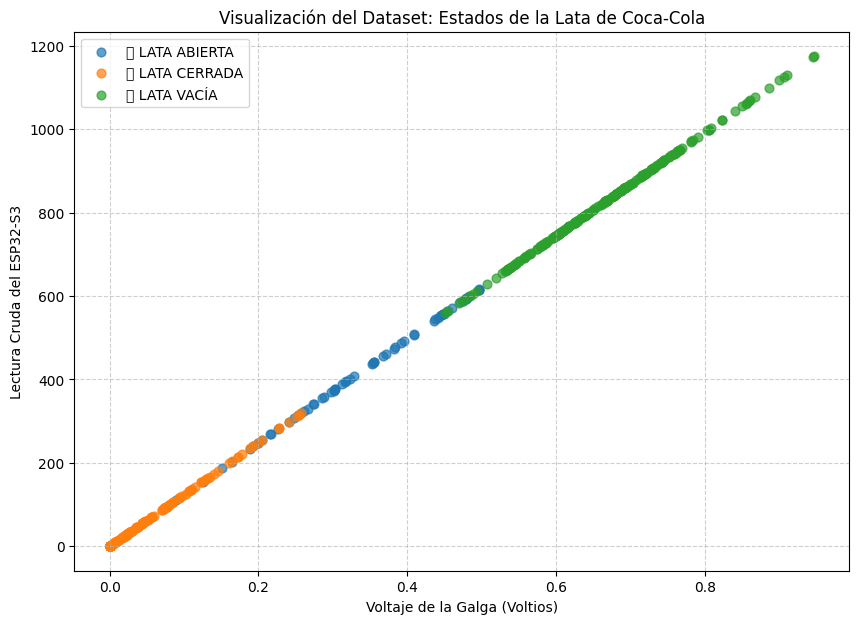

In [14]:
import matplotlib.pyplot as plt

# Configuramos el tamaño de la ventana de la gráfica
plt.figure(figsize=(10, 7))

# Cambiamos las variables de humedad/temperatura por tus 3 estados de las latas
# Recuerda que df_unificado es la tabla que contiene todos tus datos juntos
for estado_texto, nombre_mostrar in [
    ("abierta", "🔓 LATA ABIERTA"),
    ("cerrada", "🔒 LATA CERRADA"),
    ("vacia",   "🗑️ LATA VACÍA")
]:
    # Filtramos las filas que pertenecen a cada estado
    parte = df_unificado[df_unificado["Estado"] == estado_texto]

    # Dibujamos los puntos en la gráfica
    # Eje X = Voltaje, Eje Y = LecturaCruda
    plt.scatter(
        parte["Voltaje"],
        parte["LecturaCruda"],
        label=nombre_mostrar,
        alpha=0.7,  # Le da un toque de transparencia para ver puntos encimados
        s=40        # Tamaño de los puntos
    )

# Ponemos las etiquetas correctas de tu proyecto en los ejes
plt.xlabel("Voltaje de la Galga (Voltios)")
plt.ylabel("Lectura Cruda del ESP32-S3")
plt.title("Visualización del Dataset: Estados de la Lata de Coca-Cola")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Mostramos la gráfica en la pantalla de Colab
plt.show()



In [15]:
import joblib

# 1. Guardamos el modelo de la red neuronal entrenada de tus latas (Formato Keras estándar)
modelo.save("modelo_coca_cola.keras")

# 2. Guardamos el escalador (StandardScaler) que contiene la media y desviación de tus latas
joblib.dump(scaler, "scaler_coca_cola.pkl")

print("========================================")
print("💾 ¡ARCHIVOS GUARDADOS EN COLAB EXITOSAMENTE!")
print("========================================")
print("• Modelo guardado como: 'modelo_coca_cola.keras'")
print("• Escalador guardado como: 'scaler_coca_cola.pkl'")
print("\n*(Puedes verlos y descargarlos desde la carpeta 📁 de la barra izquierda)*")


💾 ¡ARCHIVOS GUARDADOS EN COLAB EXITOSAMENTE!
• Modelo guardado como: 'modelo_coca_cola.keras'
• Escalador guardado como: 'scaler_coca_cola.pkl'

*(Puedes verlos y descargarlos desde la carpeta 📁 de la barra izquierda)*


In [16]:
import tensorflow as tf

# 1. Creamos el convertidor apuntando a tu modelo de la red neuronal
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)

# 2. Realizamos la conversión al formato ultraligero .tflite
modelo_tflite = converter.convert()

# 3. Guardamos el archivo binario resultante con el nombre de tu proyecto
with open("modelo_coca_cola.tflite", "wb") as archivo:
    archivo.write(modelo_tflite)

print("========================================")
print("📦 ¡CONVERSIÓN A TINYML COMPLETADA!")
print("========================================")
print("• Archivo creado: 'modelo_coca_cola.tflite'")
print("• Tamaño final de la IA:", len(modelo_tflite), "bytes")
print("\n*(¡Ya es un archivo diminuto y optimizado para microcontroladores!)*")


Saved artifact at '/tmp/tmp77k7vano'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133803827078032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827078992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827078608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827079376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827079184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133803827078800: TensorSpec(shape=(), dtype=tf.resource, name=None)
📦 ¡CONVERSIÓN A TINYML COMPLETADA!
• Archivo creado: 'modelo_coca_cola.tflite'
• Tamaño final de la IA: 2684 bytes

*(¡Ya es un archivo diminuto y optimizado para microcontroladores!)*


In [17]:
from google.colab import files

# Descargamos el archivo comprimido definitivo de tu IA a tu computadora
files.download("modelo_coca_cola.tflite")

print("========================================")
print("📥 ¡DESCARGA INICIADA EN TU NAVEGADOR!")
print("========================================")
print("Busca en tu carpeta de descargas el archivo: 'modelo_coca_cola.tflite'")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 ¡DESCARGA INICIADA EN TU NAVEGADOR!
Busca en tu carpeta de descargas el archivo: 'modelo_coca_cola.tflite'


In [18]:
from google.colab import files

print("=== 📥 PASO 1: SELECCIONA EL ARCHIVO QUE ACABAS DE DESCARGAR ===")
# Esto abrirá un botón para que busques en tu computadora el archivo 'modelo_coca_cola.tflite'
archivo = files.upload()

nombre = list(archivo.keys())[0]

with open(nombre, "rb") as f:
    datos = f.read()

# Creamos automáticamente tu archivo de cabecera para Arduino IDE
with open("modelo_coca_cola.h", "w") as f:

    f.write("#ifndef MODELO_COCA_COLA_H\n")
    f.write("#define MODELO_COCA_COLA_H\n\n")

    f.write("// Array de bytes de la IA para el ESP32-S3\n")
    f.write("const unsigned char modelo_tflite[] = {\n")

    for i in range(0, len(datos), 12):
        bloque = datos[i:i+12]
        valores = ", ".join(f"0x{b:02x}" for b in bloque)
        f.write("    " + valores + ",\n")

    f.write("};\n\n")
    f.write(f"const unsigned int modelo_tflite_len = {len(datos)};\n\n")
    f.write("#endif\n")

print("\n========================================")
print("✨ ¡ARCHIVO C++ GENERADO CON ÉXITO!")
print("========================================")
print("• Se ha creado el archivo: 'modelo_coca_cola.h'")
print("• Tamaño procesado:", len(datos), "bytes")
print("\n*(Ahora puedes ver este archivo en la carpeta 📁 de la barra izquierda, listo para descargar)*")


=== 📥 PASO 1: SELECCIONA EL ARCHIVO QUE ACABAS DE DESCARGAR ===


Saving modelo_coca_cola.tflite to modelo_coca_cola (1).tflite

✨ ¡ARCHIVO C++ GENERADO CON ÉXITO!
• Se ha creado el archivo: 'modelo_coca_cola.h'
• Tamaño procesado: 2684 bytes

*(Ahora puedes ver este archivo en la carpeta 📁 de la barra izquierda, listo para descargar)*


In [19]:
from google.colab import files

# Descargamos automáticamente el archivo de cabecera C++ para tu Arduino
files.download("modelo_coca_cola.h")

print("========================================")
print("📥 ¡DESCARGA DEL ARCHIVO .H INICIADA!")
print("========================================")
print("Busca en tu carpeta de descargas el archivo: 'modelo_coca_cola.h'")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 ¡DESCARGA DEL ARCHIVO .H INICIADA!
Busca en tu carpeta de descargas el archivo: 'modelo_coca_cola.h'


In [20]:
print("========================================")
print("📐 VALORES DE CALIBRACIÓN PARA TU ARDUINO")
print("========================================")

print("MEDIA:")
print(scaler.mean_)

print("\nDESVIACION:")
print(scaler.scale_)


📐 VALORES DE CALIBRACIÓN PARA TU ARDUINO
MEDIA:
[4.20581948e+02 3.38900238e-01]

DESVIACION:
[3.82621624e+02 3.08315998e-01]


In [21]:
import numpy as np

# 1. Definimos tu diccionario oficial de traducción de la IA
estados = {
    0: "ABIERTA",
    1: "CERRADA",
    2: "VACIA"
}

# 2. Pegamos todas las lecturas reales que te arrojó el ESP32-S3 en tu último mensaje
# Formato: [LecturaCruda, Voltaje]
nuevas_lecturas_sensor = [
    [621, 0.500],
    [649, 0.523],
    [879, 0.708],
    [811, 0.654],
    [1111, 0.895],
    [905, 0.729],
    [902, 0.727],
    [1003, 0.808],
    [959, 0.773],
    [984, 0.793],
    [903, 0.728],
    [1247, 1.005],
    [1222, 0.985],
    [1135, 0.915],
    [1033, 0.832],
    [1099, 0.886],
    [1133, 0.913],
    [819, 0.660]
]

print("=====================================================================")
print("🔮 VEREDICTO DE LA IA EN COLAB CON TUS LECTURAS REALES DEL SENSOR")
print("=====================================================================\n")

# 3. Procesamos cada lectura una por una usando tu modelo entrenado
for cruda, voltaje in nuevas_lecturas_sensor:
    # Creamos el arreglo matemático
    dato = np.array([[cruda, voltaje]], dtype=np.float32)

    # El escalador oficial ajusta el dato (StandardScaler)
    dato_normalizado = scaler.transform(dato)

    # El modelo de TensorFlow calcula las probabilidades reales
    prediccion_colab = modelo.predict(dato_normalizado, verbose=0)

    # Obtenemos la posición con el porcentaje más alto
    clase_ganadora = np.argmax(prediccion_colab[0])
    confianza_ganadora = prediccion_colab[0][clase_ganadora] * 100

    # Extraemos el desglose de porcentajes para auditoría
    p_abierta = prediccion_colab[0][0] * 100
    p_cerrada = prediccion_colab[0][1] * 100
    p_vacia   = prediccion_colab[0][2] * 100

    # Imprimimos el reporte formateado en pantalla
    print(f"Sensor: {cruda:<4} | V: {voltaje:.3f}V ➔ [COLAB DICE]: {estados[clase_ganadora]:<8} (Confianza: {confianza_ganadora:.2f}%)")
    print(f"      [Detalle Probabilidades] ABIERTA: {p_abierta:.2f}% | CERRADA: {p_cerrada:.2f}% | VACIA: {p_vacia:.2f}%\n")


🔮 VEREDICTO DE LA IA EN COLAB CON TUS LECTURAS REALES DEL SENSOR

Sensor: 621  | V: 0.500V ➔ [COLAB DICE]: VACIA    (Confianza: 67.46%)
      [Detalle Probabilidades] ABIERTA: 32.24% | CERRADA: 0.30% | VACIA: 67.46%

Sensor: 649  | V: 0.523V ➔ [COLAB DICE]: VACIA    (Confianza: 88.39%)
      [Detalle Probabilidades] ABIERTA: 11.50% | CERRADA: 0.11% | VACIA: 88.39%

Sensor: 879  | V: 0.708V ➔ [COLAB DICE]: VACIA    (Confianza: 99.16%)
      [Detalle Probabilidades] ABIERTA: 0.84% | CERRADA: 0.00% | VACIA: 99.16%

Sensor: 811  | V: 0.654V ➔ [COLAB DICE]: VACIA    (Confianza: 98.59%)
      [Detalle Probabilidades] ABIERTA: 1.41% | CERRADA: 0.00% | VACIA: 98.59%

Sensor: 1111 | V: 0.895V ➔ [COLAB DICE]: VACIA    (Confianza: 99.86%)
      [Detalle Probabilidades] ABIERTA: 0.14% | CERRADA: 0.00% | VACIA: 99.86%

Sensor: 905  | V: 0.729V ➔ [COLAB DICE]: VACIA    (Confianza: 99.31%)
      [Detalle Probabilidades] ABIERTA: 0.69% | CERRADA: 0.00% | VACIA: 99.31%

Sensor: 902  | V: 0.727V ➔ [COLA

In [23]:
import numpy as np

print("="*75)
print("👉 COPIA TODO ESTE TEXTO COMPLETO PARA TU ARCHIVO 'cocacolaia.ino' 👈")
print("="*75 + "\n")

# Extraemos las capas del modelo secuencial
capa_dense_1 = modelo.layers[0]
capa_dense_2 = modelo.layers[1]
capa_dense_3 = modelo.layers[2]

W1, b1 = capa_dense_1.get_weights()
W2, b2 = capa_dense_2.get_weights()
W3, b3 = capa_dense_3.get_weights()

# --- IMPRIMIR CAPA 1 ---
print("const float W1[8][2] = {")
for neurona in W1.T:
    print(f"  {{{neurona[0]:.6f}f, {neurona[1]:.6f}f}},")
print("};")
print("const float b1[8] = {" + ", ".join(f"{x:.6f}f" for x in b1) + "};\n")

# --- IMPRIMIR CAPA 2 ---
print("const float W2[8][8] = {")
for neurona in W2.T:
    valores = ", ".join(f"{x:.6f}f" for x in neurona)
    print(f"  {{{valores}}},")
print("};")
print("const float b2[8] = {" + ", ".join(f"{x:.6f}f" for x in b2) + "};\n")

# --- IMPRIMIR CAPA 3 ---
print("const float W3[3][8] = {")
for neurona in W3.T:
    valores = ", ".join(f"{x:.6f}f" for x in neurona)
    print(f"  {{{valores}}},")
print("};")
print("const float b3[3] = {" + ", ".join(f"{x:.6f}f" for x in b3) + "};")


👉 COPIA TODO ESTE TEXTO COMPLETO PARA TU ARCHIVO 'cocacolaia.ino' 👈

const float W1[8][2] = {
  {-0.381300f, -0.717259f},
  {-0.629985f, 0.623742f},
  {1.012472f, 0.734520f},
  {-0.577860f, 0.013082f},
  {-1.265206f, -1.154849f},
  {-0.824057f, -0.073154f},
  {-0.153291f, -0.756301f},
  {1.040298f, 0.082727f},
};
const float b1[8] = {-0.116147f, -0.022258f, 0.069811f, 0.534275f, 0.096951f, 0.612038f, 0.619545f, 0.314966f};

const float W2[8][8] = {
  {0.344719f, -0.407096f, -0.218633f, -0.580292f, -0.119407f, 0.381936f, 0.033900f, 0.137802f},
  {0.119114f, 0.362318f, 0.357452f, 0.160321f, 0.174745f, -0.621161f, -1.061640f, 0.674716f},
  {0.881078f, 0.532303f, -0.167139f, 1.287490f, 0.680525f, 0.506255f, 0.383140f, -0.071023f},
  {-0.778304f, 0.581876f, -0.440441f, 0.446140f, -0.408708f, 0.527479f, 0.327997f, 0.070883f},
  {0.230873f, 0.566475f, 0.086362f, 0.903005f, 0.569424f, 1.130472f, 0.652006f, -0.560565f},
  {-0.592785f, -0.282193f, 0.398729f, 0.092049f, -0.208856f, -0.083116f, 0.